In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("../data/library_data.csv")
df.head()

,transaction_id,book_title,category,user_id,issue_date,return_date,fine_amount
0,1,DBMS,AI,111,2025-03-17,2025-04-04,80
1,2,Operating Systems,Tech,132,2025-02-22,2025-03-09,50
2,3,DBMS,Tech,12,2025-02-12,2025-02-24,20
3,4,DBMS,Programming,192,2025-01-12,2025-01-23,10
4,5,Python,Data Science,25,2025-03-02,2025-03-09,0


In [3]:
df['issue_date'] = pd.to_datetime(df['issue_date'])
df['return_date'] = pd.to_datetime(df['return_date'])

# Create new feature
df['borrow_days'] = (df['return_date'] - df['issue_date']).dt.days

In [6]:
#most borrowed books
df["book_title"].value_counts().head(10)

book_title
Machine Learning     526
DSA                  517
AI Basics            499
DBMS                 499
Python               492
Operating Systems    467
Name: count, dtype: int64

In [7]:
#category popularity
df['category'].value_counts()

category
AI              779
Tech            746
Programming     740
Data Science    735
Name: count, dtype: int64

In [8]:
#average borrowing duration 
df['borrow_days'].mean()

np.float64(10.670666666666667)

In [10]:
#late returns
late_returns = df[df['borrow_days'] > 10]
late_returns.shape[0]

1536

In [11]:
#total fine collected 
df['fine_amount'].sum()

np.int64(84950)

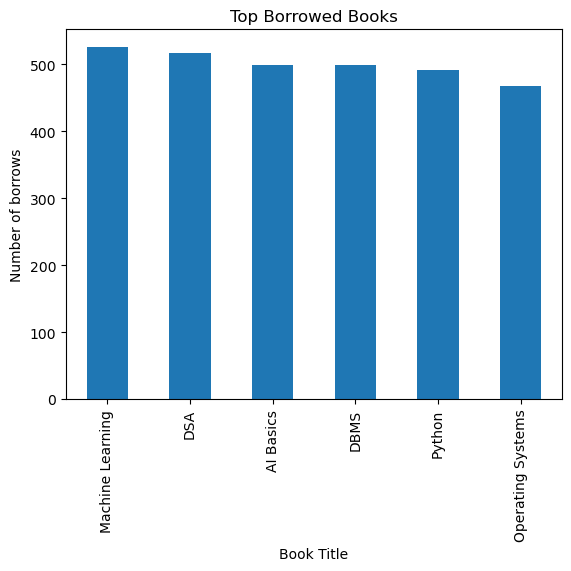

In [17]:
#visualization 
df['book_title'].value_counts().plot(kind='bar')

plt.title("Top Borrowed Books")
plt.xlabel("Book Title")
plt.ylabel("Number of borrows")
plt.savefig("../visuals/top_borrowed_book.png")
plt.show()

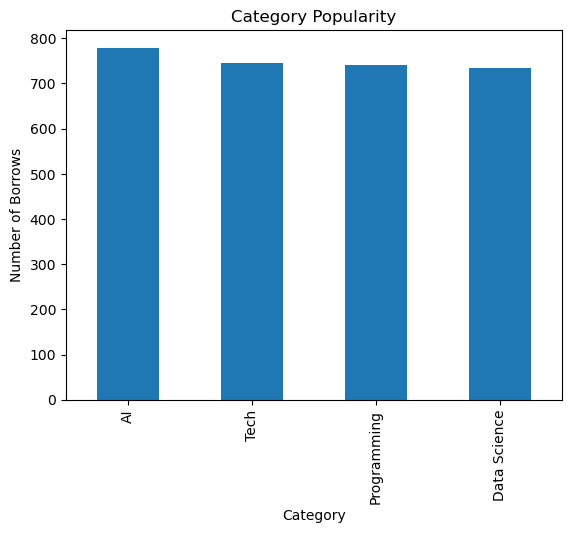

In [18]:
#category popularity 
df['category'].value_counts().plot(kind='bar')

plt.title("Category Popularity")
plt.xlabel("Category")
plt.ylabel("Number of Borrows")
plt.savefig("../visuals/category_popularity.png")
plt.show()

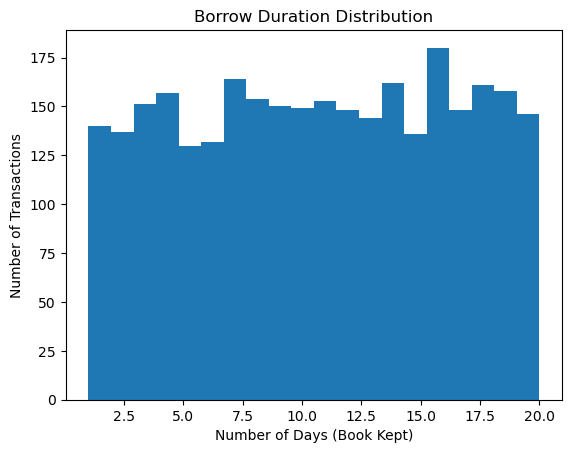

In [19]:
#borrowed duration
df['borrow_days'].plot(kind='hist', bins=20)

plt.title("Borrow Duration Distribution")
plt.xlabel("Number of Days (Book Kept)")   # X-axis
plt.ylabel("Number of Transactions")       # Y-axis

plt.savefig("../visuals/borrowed_duration.png")
plt.show()

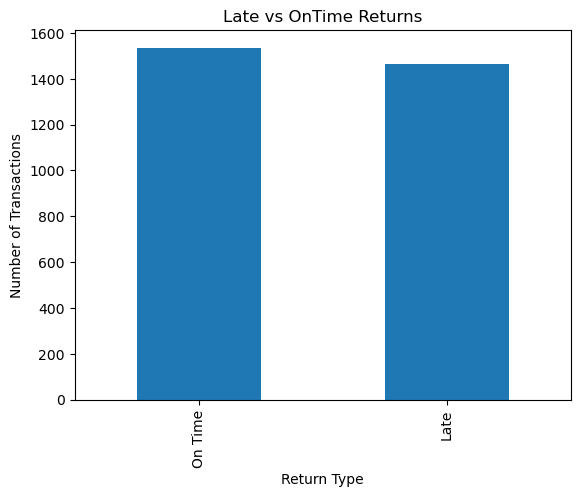

In [21]:
#late returns
late_counts = (df['borrow_days'] > 10).value_counts()

late_counts.index = ['On Time', 'Late']  # Rename properly

late_counts.plot(kind='bar')
plt.title("Late vs OnTime Returns")
plt.xlabel("Return Type")
plt.ylabel("Number of Transactions")

plt.savefig("../visuals/late_returns.png")
plt.show()

**insights**

1 - Machine Learning and DSA are the most borrowed books, indicating strong demand for technical and career-oriented resources among users.

2 - AI category shows the highest borrowing count, followed closely by Tech and Programming, suggesting a strong inclination toward emerging technologies and skill-based learning.

3- Borrow duration is fairly evenly distributed between 1–20 days, with a slight concentration around mid-range durations (10–15 days), indicating consistent user borrowing patterns.

4 - On-time returns slightly exceed late returns, indicating relatively good return discipline, although the difference is minimal.

5 - The close gap between late and on-time returns suggests a potential risk of increasing late returns if proper monitoring or reminder systems are not implemented.